In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

K= 1 | Inertia=19780.25
K= 2 | Inertia=9211.21
K= 3 | Inertia=1919.36
K= 4 | Inertia=362.47
K= 5 | Inertia=329.27
K= 6 | Inertia=294.61
K= 7 | Inertia=261.56
K= 8 | Inertia=232.01
K= 9 | Inertia=209.10
K=10 | Inertia=188.72


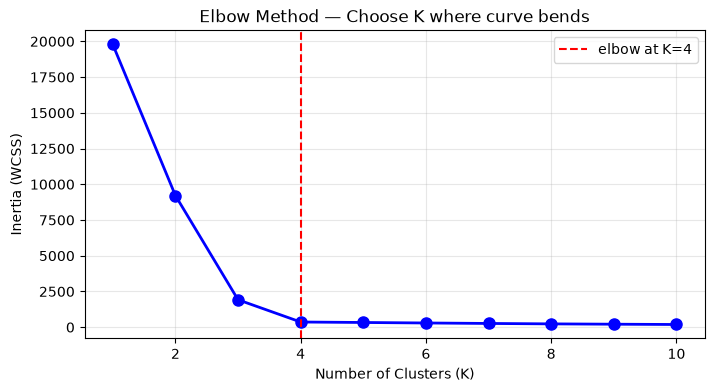

In [2]:
# Cell 2 — Version 1: Elbow method
# Plot inertia vs K — look for the "elbow" where inertia stops dropping fast

np.random.seed(42)
X, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.8, random_state=42)

inertias = []
K_range  = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X)
    inertias.append(km.inertia_)
    print(f"K={k:2d} | Inertia={km.inertia_:.2f}")

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, 'b-o', linewidth=2, markersize=8)
plt.axvline(4, color='red', linestyle='--', label='elbow at K=4')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method — Choose K where curve bends')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

K= 2 | Silhouette Score=0.6030
K= 3 | Silhouette Score=0.7783
K= 4 | Silhouette Score=0.8335
K= 5 | Silhouette Score=0.6976
K= 6 | Silhouette Score=0.5882
K= 7 | Silhouette Score=0.4487
K= 8 | Silhouette Score=0.3322
K= 9 | Silhouette Score=0.3439
K=10 | Silhouette Score=0.3588


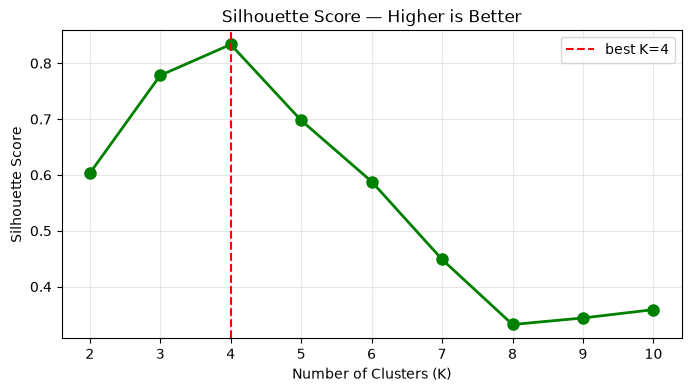


Best K by silhouette: 4


In [3]:
# Cell 3 — Version 2: Silhouette score
# Silhouette = how similar a point is to its own cluster vs other clusters
# Range: -1 (wrong cluster) to +1 (perfect cluster)
# Choose K with highest silhouette score

scores = []
for k in range(2, 11):
    km     = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X)
    score  = silhouette_score(X, labels)
    scores.append(score)
    print(f"K={k:2d} | Silhouette Score={score:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(range(2, 11), scores, 'g-o', linewidth=2, markersize=8)
plt.axvline(4, color='red', linestyle='--', label='best K=4')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score — Higher is Better')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()
print(f"\nBest K by silhouette: {range(2,11)[np.argmax(scores)]}")

K= 2 | Silhouette Score=0.6030
K= 3 | Silhouette Score=0.7783
K= 4 | Silhouette Score=0.8335
K= 5 | Silhouette Score=0.6976
K= 6 | Silhouette Score=0.5882
K= 7 | Silhouette Score=0.4487
K= 8 | Silhouette Score=0.3322
K= 9 | Silhouette Score=0.3439
K=10 | Silhouette Score=0.3588


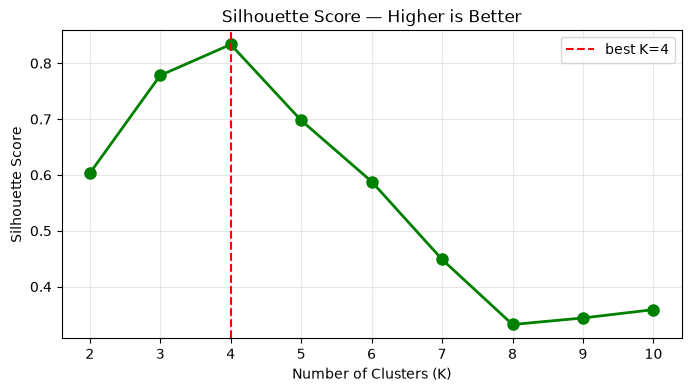


Best K by silhouette: 4


In [4]:
# Cell 3 — Version 2: Silhouette score
# Silhouette = how similar a point is to its own cluster vs other clusters
# Range: -1 (wrong cluster) to +1 (perfect cluster)
# Choose K with highest silhouette score

scores = []
for k in range(2, 11):
    km     = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X)
    score  = silhouette_score(X, labels)
    scores.append(score)
    print(f"K={k:2d} | Silhouette Score={score:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(range(2, 11), scores, 'g-o', linewidth=2, markersize=8)
plt.axvline(4, color='red', linestyle='--', label='best K=4')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score — Higher is Better')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()
print(f"\nBest K by silhouette: {range(2,11)[np.argmax(scores)]}")

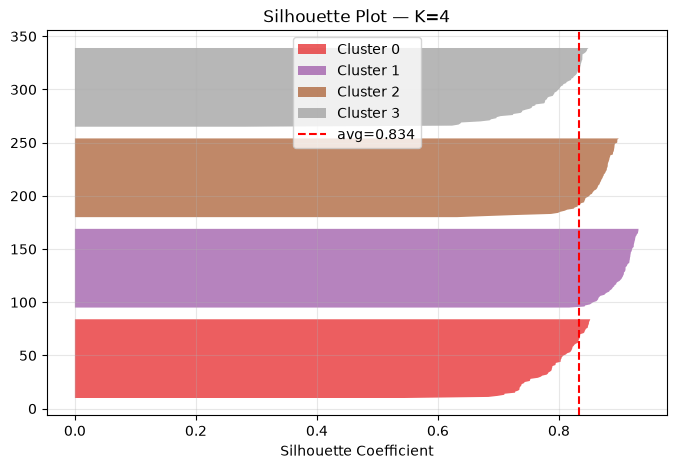

In [5]:
# Cell 4 — Version 3: silhouette plot (per-sample)
from matplotlib import cm

np.random.seed(42)
X, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.8, random_state=42)

km     = KMeans(n_clusters=4, init='k-means++', n_init=10, random_state=42)
labels = km.fit_predict(X)
sil_vals = silhouette_samples(X, labels)

fig, ax = plt.subplots(figsize=(8, 5))
y_lower = 10
colors  = cm.Set1(np.linspace(0, 1, 4))

for k in range(4):
    kth_vals = np.sort(sil_vals[labels == k])
    size_k   = len(kth_vals)
    y_upper  = y_lower + size_k
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, kth_vals,
                     facecolor=colors[k], alpha=0.7, label=f'Cluster {k}')
    y_lower  = y_upper + 10

ax.axvline(silhouette_score(X, labels), color='red', linestyle='--',
           label=f'avg={silhouette_score(X, labels):.3f}')
ax.set_xlabel('Silhouette Coefficient')
ax.set_title('Silhouette Plot — K=4')
ax.legend(); ax.grid(True, alpha=0.3); plt.show()

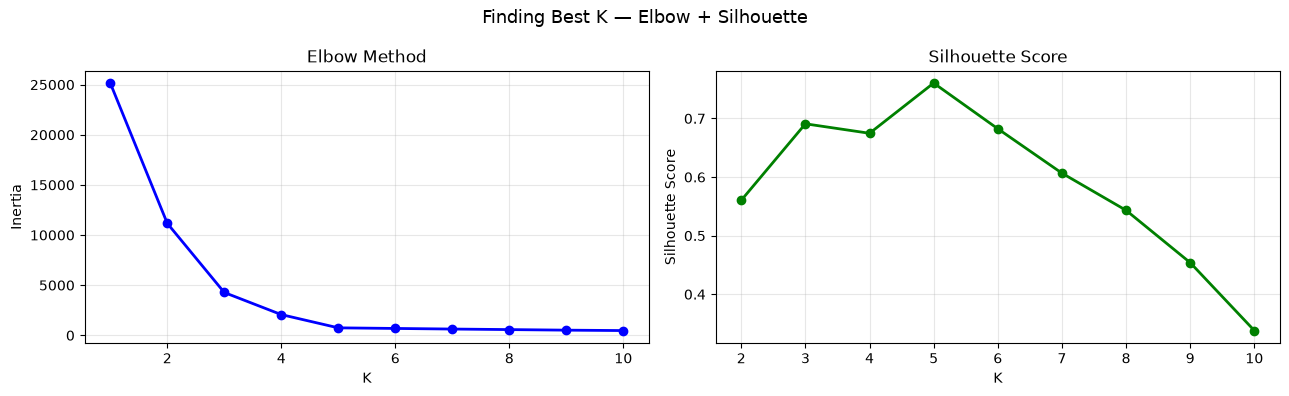

Silhouette says best K = 5


In [6]:
# Cell 5 — Version 4: elbow + silhouette side by side on unknown data
np.random.seed(7)
X_unknown, _ = make_blobs(n_samples=400, centers=5,
                           cluster_std=1.0, random_state=7)

inertias2, scores2 = [], []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_unknown)
    inertias2.append(km.inertia_)
    if k >= 2:
        scores2.append(silhouette_score(X_unknown, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(K_range, inertias2, 'b-o', linewidth=2)
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method'); axes[0].grid(True, alpha=0.3)

axes[1].plot(range(2, 11), scores2, 'g-o', linewidth=2)
axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score'); axes[1].grid(True, alpha=0.3)

plt.suptitle('Finding Best K — Elbow + Silhouette', fontsize=13)
plt.tight_layout(); plt.show()
best_k = range(2, 11)[np.argmax(scores2)]
print(f"Silhouette says best K = {best_k}")

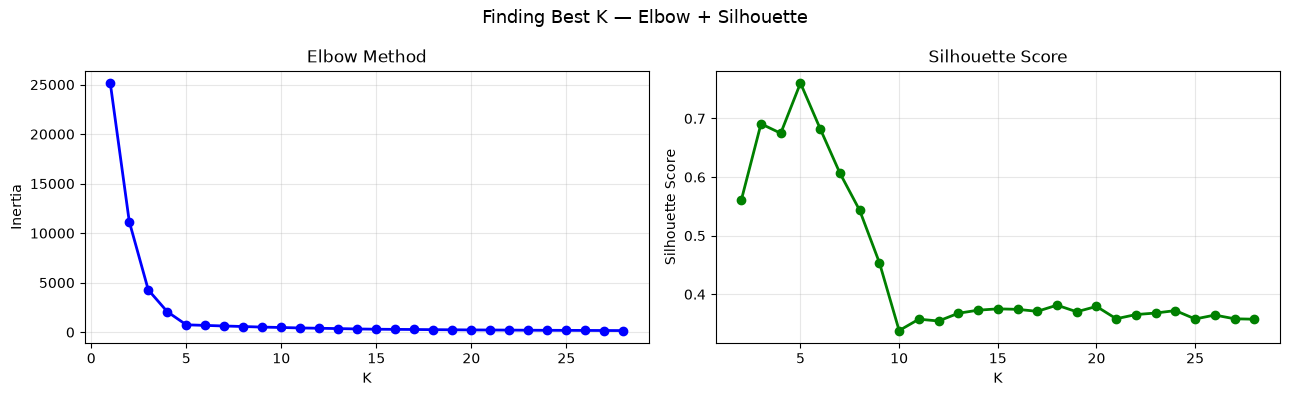

Silhouette says best K = 5


In [12]:
# Cell 5 — Version 4: elbow + silhouette side by side on unknown data
np.random.seed(7)
X_unknown, _ = make_blobs(n_samples=400, centers=5,
                           cluster_std=1.0, random_state=7)

inertias2, scores2 = [], []
K_range = range(1, 29)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_unknown)
    inertias2.append(km.inertia_)
    if k >= 2:
        scores2.append(silhouette_score(X_unknown, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(K_range, inertias2, 'b-o', linewidth=2)
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method'); axes[0].grid(True, alpha=0.3)

axes[1].plot(range(2, 29), scores2, 'g-o', linewidth=2)
axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score'); axes[1].grid(True, alpha=0.3)

plt.suptitle('Finding Best K — Elbow + Silhouette', fontsize=13)
plt.tight_layout(); plt.show()
best_k = range(2, 11)[np.argmax(scores2)]
print(f"Silhouette says best K = {best_k}")